# TYPE-EXP-004 — T4 Controlled Minibus Repair

Amaç: `TYPE-EXP-002` ile elde edilen aktif FTR araç tipi baseline'ını bozmadan, raporlanamayacak kadar düşük kalan `minibus` performansını kontrollü biçimde iyileştirmek.

Bu deney `TYPE-EXP-003`'ün doğrudan tekrarı değildir. EXP-003 dataset-level metrikleri iyileştirdi fakat lokal target ROI smoke testte `minibus` false mode üretti. Bu nedenle EXP-004'ün ana hedefi:

```text
minibus F1 yükselsin, fakat suv/panelvan/sedan/hatchback sınıflarında minibus false-positive baskısı oluşmasın.
```

FTR çıkış sınıfları değişmez:

```text
sedan, suv, hatchback, pickup, minibus, panelvan, kamyon
```

Ana farklar:

1. T4 GPU için tek backbone (`efficientnet_b0`) ve kontrollü batch/epoch ayarı kullanır.
2. `TYPE-EXP-002-efficientnet_b0-best.pth` checkpoint'inden devam eder.
3. `Vehicle-10` minibus verisini kullanır ama source/class cap ile aşırı baskılamaz.
4. Class weight ve sampler weight değerlerini clip eder; EXP-003'teki agresif minibus ağırlığını tekrarlamaz.
5. Model seçim skoruna `minibus_precision`, `minibus_false_positive_rate` ve guard sınıf macro-F1 ekler.
6. Runtime promotion için dataset metrikleri yanında 3 demo target ROI smoke test şartını açıkça yazar.

Bu notebook'un çıktısı iyi olsa bile final karar değildir; çıktı notebook'u incelenecek, checkpoint local'e indirilecek ve aynı `Test/video_1-3` target ROI video smoke testinden geçirilecektir.


## Senin Yapman Gerekenler

1. Colab Runtime: GPU seç. **T4 yeterli olacak şekilde tasarlanmıştır**. L4/A100 daha hızlıdır ama şart değildir.
2. Colab Secrets içine Kaggle bilgilerini ekle:
   - `KAGGLE_USERNAME`
   - `KAGGLE_KEY`
   - küçük harfli `kaggle_username`, `kaggle_key` de desteklenir.
3. Başlangıç checkpoint Drive'da şu konumda olmalı:

```text
/content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_type/TYPE-EXP-002-efficientnet_b0-best.pth
```

4. Notebook şu kaynakları kullanır:

```text
# EXP-002 base kaynakları
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/stanford_cars/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/car_body_type/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/mio_tcd/

# EXP-004 controlled repair kaynakları
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_003/vtid2/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_003/vehicle_10/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_004/manual/
```

5. Vehicle-10 zaten `type_exp_003/vehicle_10` altında varsa tekrar indirilmez. Yoksa notebook tar/zip indirmeyi dener.
6. Manual ek veri gerekiyorsa şu klasörleri kullan:

```text
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_004/manual/sedan/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_004/manual/suv/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_004/manual/hatchback/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_004/manual/minibus/
/content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_004/manual/panelvan/
```

7. Çalışma sonunda şu çıktıları kontrol et:
   - `TYPE-EXP-004-summary.json`
   - `TYPE-EXP-004-test_classification_report.csv`
   - `TYPE-EXP-004-test_confusion_matrix.png`
   - `TYPE-EXP-004-efficientnet_b0-best.pth`
   - `promotion_checks` alanı
   - varsa `TYPE-EXP-004-target_roi_smoke_predictions.csv`

8. Freeze kararı notebook içinde değil, notebook output + local target ROI smoke test sonrasında verilecek.


In [ ]:
# Cell 1 — Runtime setup + dependencies
import os
import sys
import json
import math
import time
import random
import shutil
import zipfile
import tarfile
import subprocess
from pathlib import Path
from collections import Counter, defaultdict

IN_COLAB = 'google.colab' in sys.modules

def run_cmd(cmd, check=True, capture_output=False, timeout=None):
    print('+', ' '.join(map(str, cmd)))
    return subprocess.run(cmd, check=check, text=True, capture_output=capture_output, timeout=timeout)

if IN_COLAB:
    run_cmd([sys.executable, '-m', 'pip', 'install', '-q', 'kaggle', 'gdown', 'scikit-learn', 'pandas', 'matplotlib', 'seaborn', 'tqdm', 'scipy'])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as T

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import train_test_split

print('IN_COLAB:', IN_COLAB)
print('Python:', sys.version)
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))


+ /usr/bin/python3 -m pip install -q kaggle gdown scikit-learn pandas matplotlib seaborn tqdm scipy
IN_COLAB: True
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Torch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA L4


In [ ]:
# Cell 2 — Drive mount + experiment configuration
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

SEED = 44
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PROJECT_ROOT = Path('/content/drive/MyDrive/anomali-road-safety-ai') if IN_COLAB else Path.cwd()
LOCAL_ROOT = Path('/content/anomali-road-safety-ai-work') if IN_COLAB else Path.cwd() / '.local_colab_work'
EXP_ID = 'TYPE-EXP-004'
PARENT_EXP_ID = 'TYPE-EXP-002'

FTR_TYPE_LABELS = ['sedan', 'suv', 'hatchback', 'pickup', 'minibus', 'panelvan', 'kamyon']
FOCUS_LABELS = ['minibus']
GUARD_LABELS = ['sedan', 'suv', 'hatchback', 'panelvan']

# Base sources keep TYPE-EXP-002 coverage for all 7 FTR classes.
ENABLE_BASE_STANFORD = True
ENABLE_BASE_CAR_BODY = True
ENABLE_BASE_MIO_TCD = True

# Controlled repair sources. VTID2 is retained for binek guard labels; Vehicle-10 is capped.
ENABLE_VTID2 = True
ENABLE_VEHICLE_10 = True
ENABLE_VEHICLE_10_AUTO_DOWNLOAD = True
VEHICLE10_DOWNLOAD_TIMEOUT_SECONDS = 600
ENABLE_MANUAL_FOCUS_FOLDERS = True

# Safety gates. EXP-004 should not repeat EXP-003's minibus over-correction.
STRICT_CLASS_COVERAGE = True
MIN_IMAGES_PER_CLASS = 180
MIN_IMAGES_PER_FOCUS_CLASS = 450
MAX_IMAGES_PER_CLASS = 3600
MAX_IMAGES_PER_SOURCE_CLASS = 1800
MAX_MINIBUS_TOTAL = 900
MAX_MINIBUS_FROM_VEHICLE10 = 650
MAX_MINIBUS_RATIO = 0.075

CLASS_TARGET_CAPS = {
    'sedan': 3400,
    'suv': 3200,
    'hatchback': 2200,
    'pickup': 3400,
    'minibus': MAX_MINIBUS_TOTAL,
    'panelvan': 3200,
    'kamyon': 3400,
}

SOURCE_CLASS_CAPS = {
    ('vehicle_10', 'minibus'): MAX_MINIBUS_FROM_VEHICLE10,
    ('stanford_cars', 'minibus'): 220,
    ('manual_ftr_type', 'minibus'): 900,
    ('vtid2', 'suv'): 800,
    ('vtid2', 'sedan'): 900,
    ('vtid2', 'hatchback'): 700,
}

# T4-friendly training controls. Continue from TYPE-EXP-002 and avoid aggressive class reweighting.
TRAIN_FROM_TYPE_EXP_002 = True
IMAGE_SIZE = 224
BATCH_SIZE = 64 if torch.cuda.is_available() else 16
NUM_WORKERS = 2 if IN_COLAB else 0
EPOCHS = 14
PATIENCE = 4
LR = 7e-5
WEIGHT_DECAY = 1e-4
UNFREEZE_BACKBONE = True
RUN_BACKBONE = 'efficientnet_b0'

# Controlled weighting. These caps are the main correction versus TYPE-EXP-003.
CLASS_WEIGHT_CLIP_MIN = 0.55
CLASS_WEIGHT_CLIP_MAX = 1.35
MINIBUS_LOSS_MULTIPLIER = 1.15
GUARD_LOSS_MULTIPLIER = 1.05
SAMPLER_WEIGHT_CLIP_MIN = 0.65
SAMPLER_WEIGHT_CLIP_MAX = 1.40
MINIBUS_SAMPLER_MULTIPLIER = 1.10
GUARD_SAMPLER_MULTIPLIER = 1.03
LABEL_SMOOTHING = 0.06

# Selection balances reportability and anti-overprediction.
SELECTION_WEIGHT_MACRO = 0.35
SELECTION_WEIGHT_GUARD = 0.25
SELECTION_WEIGHT_MINIBUS_F1 = 0.20
SELECTION_WEIGHT_MINIBUS_PRECISION = 0.10
SELECTION_WEIGHT_ACCURACY = 0.10
MINIBUS_FP_PENALTY_WEIGHT = 0.35

# Promotion targets are intentionally conservative. Local smoke remains mandatory.
PROMOTION_MIN_TEST_MACRO_F1 = 0.68
PROMOTION_MIN_MINIBUS_F1 = 0.30
PROMOTION_MIN_MINIBUS_PRECISION = 0.30
PROMOTION_MAX_MINIBUS_FALSE_POSITIVE_RATE = 0.08

# Kaggle dataset candidates.
STANFORD_KAGGLE_SLUGS = [
    'eduardo4jesus/stanford-cars-dataset',
    'jessicali9530/stanford-cars-dataset',
]
CAR_BODY_KAGGLE_SLUGS = [
    'ademboukhris/cars-body-type-cropped',
    'mayurmahurkar/stanford-car-body-type-data',
    'darshan1504/car-body-style-dataset',
]
MIO_TCD_KAGGLE_SLUGS = [
    'yash88600/miotcd-dataset-50000-imagesclassification',
]
VTID2_KAGGLE_SLUGS = [
    'sujaykapadnis/vehicle-type-image-dataset',
]

# Vehicle-10 GitHub README Google Drive file IDs.
VEHICLE10_ZIP_GDRIVE_ID = '1pNmm9RjcdTJVRl8_uv-Cs5-CahkROKHs'
VEHICLE10_TARGZ_GDRIVE_ID = '1Z2LL-vcjKnpcX2rLyBkKG577mkPcYIpR'
VEHICLE10_ZIP_URL = f'https://drive.google.com/file/d/{VEHICLE10_ZIP_GDRIVE_ID}/view?usp=sharing'
VEHICLE10_TARGZ_URL = f'https://drive.google.com/file/d/{VEHICLE10_TARGZ_GDRIVE_ID}/view?usp=sharing'

DRIVE_EXP002_DATA_ROOT = PROJECT_ROOT / 'datasets' / 'type_exp_002'
DRIVE_EXP003_DATA_ROOT = PROJECT_ROOT / 'datasets' / 'type_exp_003'
DRIVE_DATA_ROOT = PROJECT_ROOT / 'datasets' / 'type_exp_004'
DRIVE_BASE_STANFORD_ROOT = DRIVE_EXP002_DATA_ROOT / 'stanford_cars'
DRIVE_BASE_CAR_BODY_ROOT = DRIVE_EXP002_DATA_ROOT / 'car_body_type'
DRIVE_BASE_MIO_ROOT = DRIVE_EXP002_DATA_ROOT / 'mio_tcd'
# Reuse EXP-003 downloaded archives when present.
DRIVE_VTID2_ROOT = DRIVE_EXP003_DATA_ROOT / 'vtid2'
DRIVE_VEHICLE10_ROOT = DRIVE_EXP003_DATA_ROOT / 'vehicle_10'
DRIVE_MANUAL_ROOT = DRIVE_DATA_ROOT / 'manual'
DRIVE_METADATA_ROOT = DRIVE_DATA_ROOT / 'metadata'
DRIVE_RUN_ROOT = PROJECT_ROOT / 'runs' / 'vehicle_type' / EXP_ID
DRIVE_CKPT_ROOT = PROJECT_ROOT / 'models' / 'checkpoints' / 'vehicle_type'
BASE_CHECKPOINT = DRIVE_CKPT_ROOT / 'TYPE-EXP-002-efficientnet_b0-best.pth'

LOCAL_DATA_ROOT = LOCAL_ROOT / 'datasets' / 'type_exp_004'
LOCAL_BASE_STANFORD_EXTRACT = LOCAL_DATA_ROOT / 'base_stanford_cars' / 'extracted'
LOCAL_BASE_CAR_BODY_EXTRACT = LOCAL_DATA_ROOT / 'base_car_body_type' / 'extracted'
LOCAL_BASE_MIO_EXTRACT = LOCAL_DATA_ROOT / 'base_mio_tcd' / 'extracted'
LOCAL_VTID2_EXTRACT = LOCAL_DATA_ROOT / 'vtid2' / 'extracted'
LOCAL_VEHICLE10_EXTRACT = LOCAL_DATA_ROOT / 'vehicle_10' / 'extracted'
LOCAL_MANUAL_ROOT = LOCAL_DATA_ROOT / 'manual'

for p in [DRIVE_BASE_STANFORD_ROOT, DRIVE_BASE_CAR_BODY_ROOT, DRIVE_BASE_MIO_ROOT,
          DRIVE_VTID2_ROOT, DRIVE_VEHICLE10_ROOT, DRIVE_MANUAL_ROOT, DRIVE_METADATA_ROOT, DRIVE_RUN_ROOT, DRIVE_CKPT_ROOT,
          LOCAL_BASE_STANFORD_EXTRACT, LOCAL_BASE_CAR_BODY_EXTRACT, LOCAL_BASE_MIO_EXTRACT,
          LOCAL_VTID2_EXTRACT, LOCAL_VEHICLE10_EXTRACT, LOCAL_MANUAL_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DRIVE_DATA_ROOT:', DRIVE_DATA_ROOT)
print('LOCAL_DATA_ROOT:', LOCAL_DATA_ROOT)
print('BASE_CHECKPOINT:', BASE_CHECKPOINT, 'exists:', BASE_CHECKPOINT.exists())
print('FTR labels:', FTR_TYPE_LABELS)
print('FOCUS labels:', FOCUS_LABELS)
print('GUARD labels:', GUARD_LABELS)
print('T4 config -> BATCH_SIZE:', BATCH_SIZE, 'EPOCHS:', EPOCHS, 'LR:', LR)
print('Minibus controls:', {'MAX_MINIBUS_TOTAL': MAX_MINIBUS_TOTAL, 'MAX_MINIBUS_FROM_VEHICLE10': MAX_MINIBUS_FROM_VEHICLE10, 'MAX_MINIBUS_RATIO': MAX_MINIBUS_RATIO})


Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/anomali-road-safety-ai
DRIVE_DATA_ROOT: /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_004
LOCAL_DATA_ROOT: /content/anomali-road-safety-ai-work/datasets/type_exp_004
BASE_CHECKPOINT: /content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_type/TYPE-EXP-002-efficientnet_b0-best.pth exists: True
FTR labels: ['sedan', 'suv', 'hatchback', 'pickup', 'minibus', 'panelvan', 'kamyon']
FOCUS labels: ['minibus']
GUARD labels: ['sedan', 'suv', 'hatchback', 'panelvan']
T4 config -> BATCH_SIZE: 64 EPOCHS: 14 LR: 7e-05
Minibus controls: {'MAX_MINIBUS_TOTAL': 900, 'MAX_MINIBUS_FROM_VEHICLE10': 650, 'MAX_MINIBUS_RATIO': 0.075}


In [ ]:
# Cell 3 — Kaggle / gdown auth + dataset acquisition helpers
import getpass

IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def setup_kaggle_credentials():
    kaggle_dir = Path.home() / '.kaggle'
    kaggle_dir.mkdir(parents=True, exist_ok=True)
    kaggle_json = kaggle_dir / 'kaggle.json'

    username = os.environ.get('KAGGLE_USERNAME') or os.environ.get('kaggle_username')
    key = os.environ.get('KAGGLE_KEY') or os.environ.get('kaggle_key')

    if IN_COLAB and (not username or not key):
        try:
            from google.colab import userdata
            username = username or userdata.get('KAGGLE_USERNAME') or userdata.get('kaggle_username')
            key = key or userdata.get('KAGGLE_KEY') or userdata.get('kaggle_key')
        except Exception as exc:
            print('Colab Secrets read skipped/failed:', exc)

    if not username or not key:
        print('Kaggle credentials missing. Kaggle sources will be skipped unless zip files already exist in Drive.')
        return None

    kaggle_json.write_text(json.dumps({'username': username, 'key': key}), encoding='utf-8')
    kaggle_json.chmod(0o600)
    print('Kaggle credentials ready:', kaggle_json)
    return kaggle_json

KAGGLE_JSON = setup_kaggle_credentials()

def count_images(root):
    root = Path(root)
    if not root.exists():
        return 0
    return sum(1 for p in root.rglob('*') if p.suffix.lower() in IMAGE_EXTS)

def extract_archive_if_needed(archive_path, extract_dir, marker_name=None):
    archive_path = Path(archive_path)
    extract_dir = Path(extract_dir)
    marker = extract_dir / (marker_name or (archive_path.name + '.extracted.marker'))
    if marker.exists() and count_images(extract_dir) > 0:
        print('Already extracted:', archive_path, 'images:', count_images(extract_dir))
        return True
    print('Extracting:', archive_path, '->', extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)
    suffixes = ''.join(archive_path.suffixes).lower()
    if archive_path.suffix.lower() == '.zip':
        with zipfile.ZipFile(archive_path, 'r') as zf:
            zf.extractall(extract_dir)
    elif suffixes.endswith('.tar.gz') or archive_path.suffix.lower() in {'.tar', '.tgz'}:
        with tarfile.open(archive_path, 'r:*') as tf:
            tf.extractall(extract_dir)
    else:
        raise ValueError('Unsupported archive: ' + str(archive_path))
    marker.write_text(time.strftime('%Y-%m-%d %H:%M:%S'), encoding='utf-8')
    print('Extracted images:', count_images(extract_dir))
    return True

def find_existing_archive(root):
    root = Path(root)
    if not root.exists():
        return None
    candidates = []
    for pattern in ['*.zip', '*.tar.gz', '*.tgz', '*.tar']:
        candidates.extend(root.glob(pattern))
    candidates = sorted(candidates, key=lambda p: p.stat().st_size if p.exists() else 0, reverse=True)
    return candidates[0] if candidates else None

def download_kaggle_dataset(slugs, drive_root, local_extract, source_name):
    drive_root = Path(drive_root)
    local_extract = Path(local_extract)
    drive_root.mkdir(parents=True, exist_ok=True)
    local_extract.mkdir(parents=True, exist_ok=True)

    if count_images(local_extract) > 0:
        print(f'{source_name}: local extract already has images:', count_images(local_extract))
        return True

    existing_archive = find_existing_archive(drive_root)
    if existing_archive is not None:
        print(f'{source_name}: using existing Drive archive:', existing_archive, 'size MB:', round(existing_archive.stat().st_size / 1e6, 2))
        return extract_archive_if_needed(existing_archive, local_extract)

    if KAGGLE_JSON is None:
        print(f'{source_name}: no Kaggle credentials and no Drive archive; skipped.')
        return False

    last_error = None
    for slug in slugs:
        print(f'Downloading {source_name} from Kaggle:', slug)
        try:
            run_cmd(['kaggle', 'datasets', 'download', '-d', slug, '-p', str(drive_root)], check=True)
            existing_archive = find_existing_archive(drive_root)
            if existing_archive is None:
                raise RuntimeError('Kaggle command completed but no archive found under ' + str(drive_root))
            return extract_archive_if_needed(existing_archive, local_extract)
        except Exception as exc:
            last_error = exc
            print(f'{source_name}: Kaggle slug failed:', slug, '|', repr(exc))
    print(f'{source_name}: all Kaggle slugs failed. Last error:', repr(last_error))
    return False

def download_gdrive_archive(file_id, drive_url, drive_root, target_name, local_extract, source_name, timeout_seconds=600):
    drive_root = Path(drive_root)
    local_extract = Path(local_extract)
    drive_root.mkdir(parents=True, exist_ok=True)
    local_extract.mkdir(parents=True, exist_ok=True)

    if count_images(local_extract) > 0:
        print(f'{source_name}: local extract already has images:', count_images(local_extract))
        return True

    existing_archive = find_existing_archive(drive_root)
    if existing_archive is not None:
        print(f'{source_name}: using existing Drive archive:', existing_archive, 'size MB:', round(existing_archive.stat().st_size / 1e6, 2))
        return extract_archive_if_needed(existing_archive, local_extract)

    target_path = drive_root / target_name
    tmp_path = drive_root / (target_name + '.part')
    for stale in [tmp_path, target_path]:
        if stale.exists() and stale.stat().st_size < 10_000_000:
            stale.unlink()
            print(f'{source_name}: removed stale/incomplete archive:', stale)
    try:
        cmd = ['gdown', '--fuzzy', drive_url, '-O', str(tmp_path), '--continue']
        print(f'{source_name}: attempting gdown with timeout={timeout_seconds}s')
        run_cmd(cmd, check=True, timeout=timeout_seconds)
        if not tmp_path.exists() or tmp_path.stat().st_size < 10_000_000:
            raise RuntimeError('gdown output missing or too small: ' + str(tmp_path))
        if target_path.exists():
            target_path.unlink()
        tmp_path.rename(target_path)
        print(f'{source_name}: downloaded archive:', target_path, 'size MB:', round(target_path.stat().st_size / 1e6, 2))
        return extract_archive_if_needed(target_path, local_extract)
    except subprocess.TimeoutExpired as exc:
        print(f'{source_name}: gdown timed out after {timeout_seconds}s:', repr(exc))
    except Exception as exc:
        print(f'{source_name}: gdown failed:', repr(exc))
    finally:
        if tmp_path.exists() and tmp_path.stat().st_size < 10_000_000:
            tmp_path.unlink()
            print(f'{source_name}: removed incomplete temp archive:', tmp_path)
    print('Manual fallback: place Vehicle-10 zip/tar.gz under', drive_root)
    print('Vehicle-10 zip URL:', VEHICLE10_ZIP_URL)
    print('Vehicle-10 tar.gz URL:', VEHICLE10_TARGZ_URL)
    return False

def copy_manual_if_needed():
    if not DRIVE_MANUAL_ROOT.exists() or count_images(DRIVE_MANUAL_ROOT) == 0:
        print('Manual focus folder is empty/skipped:', DRIVE_MANUAL_ROOT)
        return False
    if count_images(LOCAL_MANUAL_ROOT) > 0:
        print('Manual local folder already has images:', count_images(LOCAL_MANUAL_ROOT))
        return True
    print('Copying manual focus folders to local runtime. This avoids slow Drive reads during training.')
    if LOCAL_MANUAL_ROOT.exists():
        shutil.rmtree(LOCAL_MANUAL_ROOT)
    shutil.copytree(DRIVE_MANUAL_ROOT, LOCAL_MANUAL_ROOT)
    print('Manual local images:', count_images(LOCAL_MANUAL_ROOT))
    return True

if ENABLE_BASE_STANFORD:
    download_kaggle_dataset(STANFORD_KAGGLE_SLUGS, DRIVE_BASE_STANFORD_ROOT, LOCAL_BASE_STANFORD_EXTRACT, 'Base Stanford Cars')
if ENABLE_BASE_CAR_BODY:
    download_kaggle_dataset(CAR_BODY_KAGGLE_SLUGS, DRIVE_BASE_CAR_BODY_ROOT, LOCAL_BASE_CAR_BODY_EXTRACT, 'Base Car Body Type')
if ENABLE_BASE_MIO_TCD:
    download_kaggle_dataset(MIO_TCD_KAGGLE_SLUGS, DRIVE_BASE_MIO_ROOT, LOCAL_BASE_MIO_EXTRACT, 'Base MIO-TCD classification subset')
if ENABLE_VTID2:
    download_kaggle_dataset(VTID2_KAGGLE_SLUGS, DRIVE_VTID2_ROOT, LOCAL_VTID2_EXTRACT, 'Focus VTID2 Vehicle Type Image Dataset')
if ENABLE_VEHICLE_10:
    existing_vehicle10_archive = find_existing_archive(DRIVE_VEHICLE10_ROOT)
    if existing_vehicle10_archive is not None:
        print('Focus Vehicle-10: using existing manual/Drive archive first:', existing_vehicle10_archive)
        extract_archive_if_needed(existing_vehicle10_archive, LOCAL_VEHICLE10_EXTRACT)
    elif ENABLE_VEHICLE_10_AUTO_DOWNLOAD:
        # Prefer tar.gz first; it is usually friendlier on Linux Colab than the zip package.
        ok_vehicle10 = download_gdrive_archive(VEHICLE10_TARGZ_GDRIVE_ID, VEHICLE10_TARGZ_URL, DRIVE_VEHICLE10_ROOT, 'vehicle-10.tar.gz', LOCAL_VEHICLE10_EXTRACT, 'Focus Vehicle-10 tar.gz', timeout_seconds=VEHICLE10_DOWNLOAD_TIMEOUT_SECONDS)
        if not ok_vehicle10:
            download_gdrive_archive(VEHICLE10_ZIP_GDRIVE_ID, VEHICLE10_ZIP_URL, DRIVE_VEHICLE10_ROOT, 'vehicle-10.zip', LOCAL_VEHICLE10_EXTRACT, 'Focus Vehicle-10 zip', timeout_seconds=VEHICLE10_DOWNLOAD_TIMEOUT_SECONDS)
    else:
        print('Focus Vehicle-10 auto download disabled. Place vehicle-10.zip or vehicle-10.tar.gz under:', DRIVE_VEHICLE10_ROOT)
if ENABLE_MANUAL_FOCUS_FOLDERS:
    copy_manual_if_needed()

print('Image counts:')
print('  Base Stanford:', count_images(LOCAL_BASE_STANFORD_EXTRACT))
print('  Base Car body:', count_images(LOCAL_BASE_CAR_BODY_EXTRACT))
print('  Base MIO-TCD:', count_images(LOCAL_BASE_MIO_EXTRACT))
print('  VTID2:', count_images(LOCAL_VTID2_EXTRACT))
print('  Vehicle-10:', count_images(LOCAL_VEHICLE10_EXTRACT))
print('  Manual focus:', count_images(LOCAL_MANUAL_ROOT))


Kaggle credentials ready: /root/.kaggle/kaggle.json
Base Stanford Cars: using existing Drive archive: /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/stanford_cars/stanford-cars-dataset.zip size MB: 1959.4
Extracting: /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/stanford_cars/stanford-cars-dataset.zip -> /content/anomali-road-safety-ai-work/datasets/type_exp_004/base_stanford_cars/extracted
Extracted images: 16185
Base Car Body Type: using existing Drive archive: /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/car_body_type/cars-body-type-cropped.zip size MB: 1440.31
Extracting: /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_002/car_body_type/cars-body-type-cropped.zip -> /content/anomali-road-safety-ai-work/datasets/type_exp_004/base_car_body_type/extracted
Extracted images: 7549
Base MIO-TCD classification subset: using existing Drive archive: /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_ex

In [ ]:
# Cell 4 — FTR type mapping helpers
import re
try:
    from scipy.io import loadmat
except Exception as exc:
    loadmat = None
    print('scipy.io.loadmat unavailable:', exc)

def normalize_text(value):
    value = str(value).lower().strip()
    replace = {'ı':'i','İ':'i','ş':'s','Ş':'s','ğ':'g','Ğ':'g','ü':'u','Ü':'u','ö':'o','Ö':'o','ç':'c','Ç':'c'}
    for src, dst in replace.items():
        value = value.replace(src, dst)
    value = re.sub(r'[^a-z0-9]+', '_', value)
    value = re.sub(r'_+', '_', value).strip('_')
    return value

def tokens(value):
    return [t for t in normalize_text(value).split('_') if t]

def has_phrase(norm, phrase):
    phrase = normalize_text(phrase)
    return bool(re.search(r'(^|_)' + re.escape(phrase) + r'($|_)', norm))

# Conservative aliases. Avoid substring matching: "van" must not match "vantage".
DIRECT_ALIASES = {
    'sedan': 'sedan', 'saloon': 'sedan',
    'suv': 'suv', 'sport_utility_vehicle': 'suv', 'crossover': 'suv',
    'hatchback': 'hatchback', 'hatch': 'hatchback',
    'pickup': 'pickup', 'pick_up': 'pickup', 'pickup_truck': 'pickup',
    'minibus': 'minibus', 'minivan': 'minibus', 'mini_van': 'minibus', 'microbus': 'minibus',
    'panelvan': 'panelvan', 'panel_van': 'panelvan', 'cargo_van': 'panelvan', 'work_van': 'panelvan',
    'kamyon': 'kamyon', 'truck': 'kamyon', 'lorry': 'kamyon', 'single_unit_truck': 'kamyon', 'articulated_truck': 'kamyon', 'box_truck': 'kamyon',
}

STANFORD_RULES = [
    ('pickup', ['regular_cab', 'extended_cab', 'crew_cab', 'pickup', 'f_150', 'ram_1500', 'silverado', 'tundra', 'tacoma', 'frontier']),
    ('kamyon', ['freightliner_box_truck', 'box_truck', 'dump_truck']),
    ('panelvan', ['cargo_van', 'panel_van', 'sprinter', 'express_cargo', 'savana', 'e_series']),
    ('minibus', ['minivan', 'caravan', 'odyssey', 'sienna', 'town_and_country']),
    ('suv', ['suv', 'durango', 'expedition', 'navigator', 'range_rover', 'wrangler', 'xterra', 'suburban', 'tahoe', 'yukon', 'cherokee', 'pathfinder', 'rav4', 'cr_v']),
    ('hatchback', ['hatchback', 'golf', 'focus_hatchback', 'fiesta', 'accent_hatchback', 'cooper_hatchback', 'beetle']),
    ('sedan', ['sedan', 'accord', 'camry', 'corolla', 'civic', 'altima', 'malibu', 'impala', 'charger_sedan', 'sonata', 'elantra']),
]

UNSUPPORTED_BODY_TOKENS = {'coupe', 'convertible', 'roadster', 'wagon', 'limousine', 'limousine', 'cab_chassis'}

# Dataset-specific class-folder mapping.
MIO_CLASS_MAP = {
    'pickup_truck': 'pickup',
    'pickup': 'pickup',
    'work_van': 'panelvan',
    'single_unit_truck': 'kamyon',
    'articulated_truck': 'kamyon',
    'truck': 'kamyon',
}
CAR_BODY_CLASS_MAP = {
    'sedan': 'sedan',
    'suv': 'suv',
    'hatchback': 'hatchback',
    'hatchbacks': 'hatchback',
    'pick_up': 'pickup',
    'pickup': 'pickup',
    'pickup_truck': 'pickup',
    'van': 'panelvan',
    'vans': 'panelvan',
    'panelvan': 'panelvan',
}
VTID2_CLASS_MAP = {
    'sedan': 'sedan',
    'seden': 'sedan',
    'suv': 'suv',
    'hatchback': 'hatchback',
    'pickup': 'pickup',
}
VEHICLE10_CLASS_MAP = {
    # Vehicle-10 contains a dedicated minibus class. Generic bus is intentionally skipped.
    'minibus': 'minibus',
}

# Direct manual folders are trusted if folder name is exactly an FTR label or alias.
MANUAL_CLASS_MAP = {**DIRECT_ALIASES, **{x: x for x in FTR_TYPE_LABELS}}

# Explicit overrides for known Stanford-style labels.
EXPLICIT_NAME_OVERRIDES = {
    'dodge_caravan_minivan_1997': 'minibus',
    'ford_e_series_wagon_van_2012': 'panelvan',
    'gmc_savana_van_2012': 'panelvan',
    'mercedes_benz_sprinter_van_2012': 'panelvan',
    'freightliner_box_truck': 'kamyon',
}

def map_from_alias(norm, alias_map):
    parts = set(norm.split('_'))
    for alias, label in alias_map.items():
        alias_norm = normalize_text(alias)
        if alias_norm in parts or has_phrase(norm, alias_norm):
            return label, f'alias:{alias_norm}'
    return None, 'no_alias'

def map_stanford_class_name(class_name):
    norm = normalize_text(class_name)
    if norm in EXPLICIT_NAME_OVERRIDES:
        return EXPLICIT_NAME_OVERRIDES[norm], 'explicit_override'
    for bad in UNSUPPORTED_BODY_TOKENS:
        if has_phrase(norm, bad):
            return None, 'unsupported_body:' + bad
    for label, phrases in STANFORD_RULES:
        for phrase in phrases:
            if has_phrase(norm, phrase):
                return label, 'stanford_rule:' + phrase
    label, reason = map_from_alias(norm, DIRECT_ALIASES)
    if label:
        return label, reason
    return None, 'no_reliable_type_token'

def map_folder_name(folder_name, source_dataset):
    norm = normalize_text(folder_name)
    if source_dataset == 'mio_tcd':
        label, reason = map_from_alias(norm, MIO_CLASS_MAP)
        return label, reason if label else 'mio_unmapped:' + norm
    if source_dataset == 'car_body_type':
        label, reason = map_from_alias(norm, CAR_BODY_CLASS_MAP)
        return label, reason if label else 'car_body_unmapped:' + norm
    if source_dataset == 'vtid2':
        label, reason = map_from_alias(norm, VTID2_CLASS_MAP)
        return label, reason if label else 'vtid2_unmapped:' + norm
    if source_dataset == 'vehicle_10':
        label, reason = map_from_alias(norm, VEHICLE10_CLASS_MAP)
        return label, reason if label else 'vehicle10_unmapped:' + norm
    if source_dataset == 'manual_ftr_type':
        label, reason = map_from_alias(norm, MANUAL_CLASS_MAP)
        return label, reason if label else 'manual_unmapped:' + norm
    label, reason = map_from_alias(norm, DIRECT_ALIASES)
    return label, reason

for sample in ['Honda Accord Sedan 2012', 'Dodge Durango SUV 2012', 'Ford F-150 Regular Cab 2012', 'Dodge Caravan Minivan 1997', 'Mercedes-Benz Sprinter Van 2012', 'Freightliner Box Truck', 'Aston Martin V8 Vantage Coupe 2012', 'work van', 'single unit truck']:
    if sample in ['work van', 'single unit truck']:
        print(sample, '->', map_folder_name(sample, 'mio_tcd'))
    else:
        print(sample, '->', map_stanford_class_name(sample))
print('VTID2 Seden ->', map_folder_name('Seden', 'vtid2'))
print('Vehicle-10 minibus ->', map_folder_name('minibus', 'vehicle_10'))
print('Vehicle-10 bus ->', map_folder_name('bus', 'vehicle_10'))


Honda Accord Sedan 2012 -> ('sedan', 'stanford_rule:sedan')
Dodge Durango SUV 2012 -> ('suv', 'stanford_rule:suv')
Ford F-150 Regular Cab 2012 -> ('pickup', 'stanford_rule:regular_cab')
Dodge Caravan Minivan 1997 -> ('minibus', 'explicit_override')
Mercedes-Benz Sprinter Van 2012 -> ('panelvan', 'explicit_override')
Freightliner Box Truck -> ('kamyon', 'explicit_override')
Aston Martin V8 Vantage Coupe 2012 -> (None, 'unsupported_body:coupe')
work van -> ('panelvan', 'alias:work_van')
single unit truck -> ('kamyon', 'alias:single_unit_truck')
VTID2 Seden -> ('sedan', 'alias:seden')
Vehicle-10 minibus -> ('minibus', 'alias:minibus')
Vehicle-10 bus -> (None, 'vehicle10_unmapped:bus')


In [ ]:
# Cell 5 — Metadata collectors

def image_files(root):
    root = Path(root)
    if not root.exists():
        return []
    return [p for p in root.rglob('*') if p.is_file() and p.suffix.lower() in IMAGE_EXTS]

def safe_rel(path, root):
    try:
        return str(Path(path).relative_to(root))
    except Exception:
        return str(path)

def limit_records_per_source_class(records, max_per_source_class=MAX_IMAGES_PER_SOURCE_CLASS):
    by_key = defaultdict(list)
    for r in records:
        key = (r['source_dataset'], r['source_class'], r['ftr_type'])
        by_key[key].append(r)
    limited = []
    rng = random.Random(SEED)
    for key, rows in by_key.items():
        rows = rows[:]
        rng.shuffle(rows)
        limited.extend(rows[:max_per_source_class])
    return limited

def collect_class_folder_records(root, source_dataset, folder_map_source=None):
    root = Path(root)
    records, skipped = [], []
    if not root.exists():
        return records, skipped
    files = image_files(root)
    for path in files:
        rel_parts = Path(path).relative_to(root).parts
        candidate_parts = list(rel_parts[:-1])
        found = None
        for part in reversed(candidate_parts):
            label, reason = map_folder_name(part, folder_map_source or source_dataset)
            if label in FTR_TYPE_LABELS:
                found = (label, reason, part)
                break
        if found:
            label, reason, source_class = found
            records.append({
                'image_path': str(path),
                'ftr_type': label,
                'source_dataset': source_dataset,
                'source_class': normalize_text(source_class),
                'source_id': path.stem,
                'mapping_rule': reason,
                'group_id': f'{source_dataset}:{normalize_text(source_class)}',
                'source_relpath': safe_rel(path, root),
            })
        else:
            skipped.append({
                'image_path': str(path),
                'source_dataset': source_dataset,
                'reason': 'no_mapped_folder_in_path',
                'source_relpath': safe_rel(path, root),
            })
    return limit_records_per_source_class(records), skipped

# Stanford .mat utilities

def mat_to_scalar(value):
    arr = np.asarray(value)
    while isinstance(arr, np.ndarray) and arr.size == 1:
        arr = arr.item()
    if isinstance(arr, bytes):
        return arr.decode('utf-8')
    return str(arr)

def flatten_mat_strings(value):
    arr = np.asarray(value).squeeze()
    out = []
    for item in arr.flat:
        if isinstance(item, np.ndarray):
            item = item.squeeze()
            if item.size == 1:
                item = item.item()
        if isinstance(item, bytes):
            out.append(item.decode('utf-8'))
        else:
            out.append(str(item))
    return out

def load_stanford_class_names(root):
    if loadmat is None:
        return {}
    for mat_path in root.rglob('cars_meta.mat'):
        try:
            mat = loadmat(mat_path)
        except Exception as exc:
            print('Could not read meta mat:', mat_path, exc)
            continue
        raw_names = mat.get('class_names')
        if raw_names is None:
            raw_names = mat.get('classNames')
        if raw_names is None:
            continue
        names = flatten_mat_strings(raw_names)
        return {idx + 1: name for idx, name in enumerate(names)}
    return {}

def parse_stanford_annotations(annotation_mat, class_names):
    if loadmat is None:
        return []
    try:
        mat = loadmat(annotation_mat)
    except Exception as exc:
        print('Could not read annotation mat:', annotation_mat, exc)
        return []
    raw = mat.get('annotations')
    if raw is None:
        raw = mat.get('annos')
    if raw is None:
        return []
    arr = np.asarray(raw).squeeze()
    rows = []
    for item in arr.flat:
        try:
            # Stanford Cars annotation commonly has fields: bbox_x1, bbox_y1, bbox_x2, bbox_y2, class, fname.
            names = getattr(item, 'dtype', None).names if hasattr(item, 'dtype') else None
            if not names:
                continue
            data = {name: item[name] for name in names}
            fname_key = 'fname' if 'fname' in data else ('filename' if 'filename' in data else None)
            class_key = 'class' if 'class' in data else ('class_id' if 'class_id' in data else None)
            if not fname_key or not class_key:
                continue
            fname = mat_to_scalar(data[fname_key]).strip()
            class_id = int(float(mat_to_scalar(data[class_key]).strip()))
            class_name = class_names.get(class_id, str(class_id))
            rows.append((fname, class_id, class_name))
        except Exception:
            continue
    return rows

def find_file_by_name(root, filename):
    matches = list(Path(root).rglob(filename))
    return matches[0] if matches else None

def collect_stanford_annotation_records(root, source_dataset='stanford_cars'):
    root = Path(root)
    records, skipped = [], []
    class_names = load_stanford_class_names(root)
    if not class_names:
        print('Stanford class names not found; annotation parser unavailable.')
        return records, skipped
    annotation_mats = [p for p in root.rglob('*.mat') if 'anno' in p.name.lower()]
    if not annotation_mats:
        print('Stanford annotation .mat files not found; annotation parser unavailable.')
        return records, skipped
    file_index = {p.name: p for p in image_files(root)}
    for ann_path in annotation_mats:
        rows = parse_stanford_annotations(ann_path, class_names)
        for fname, class_id, class_name in rows:
            img = file_index.get(Path(fname).name)
            if img is None:
                skipped.append({'image_path': fname, 'source_dataset': source_dataset, 'reason': 'missing_image_for_annotation', 'source_class': class_name})
                continue
            label, reason = map_stanford_class_name(class_name)
            if label in FTR_TYPE_LABELS:
                records.append({
                    'image_path': str(img),
                    'ftr_type': label,
                    'source_dataset': source_dataset,
                    'source_class': normalize_text(class_name),
                    'source_id': Path(fname).stem,
                    'mapping_rule': reason,
                    'group_id': f'{source_dataset}:{class_id}:{normalize_text(class_name)}',
                    'source_relpath': safe_rel(img, root),
                })
            else:
                skipped.append({'image_path': str(img), 'source_dataset': source_dataset, 'reason': reason, 'source_class': class_name, 'source_relpath': safe_rel(img, root)})
    return limit_records_per_source_class(records), skipped

In [ ]:
# Cell 6 — Build multi-source metadata
all_records = []
all_skipped = []

def add_records(name, root, source_dataset, folder_map_source=None, stanford=False):
    global all_records, all_skipped
    if count_images(root) <= 0:
        print(name, 'skipped: no images under', root)
        return
    if stanford:
        rec, skip = collect_stanford_annotation_records(root, source_dataset)
        if not rec:
            print(name, 'annotation parser produced 0 records; trying class-folder parser.')
            rec, skip = collect_class_folder_records(root, source_dataset, folder_map_source='manual_ftr_type')
    else:
        rec, skip = collect_class_folder_records(root, source_dataset, folder_map_source=folder_map_source or source_dataset)
    print(name, 'records:', len(rec), 'skipped:', len(skip))
    all_records.extend(rec)
    all_skipped.extend(skip)

if ENABLE_BASE_STANFORD:
    add_records('Base Stanford', LOCAL_BASE_STANFORD_EXTRACT, 'stanford_cars', stanford=True)
if ENABLE_BASE_CAR_BODY:
    add_records('Base Car Body', LOCAL_BASE_CAR_BODY_EXTRACT, 'car_body_type', folder_map_source='car_body_type')
if ENABLE_BASE_MIO_TCD:
    add_records('Base MIO-TCD', LOCAL_BASE_MIO_EXTRACT, 'mio_tcd', folder_map_source='mio_tcd')
if ENABLE_VTID2:
    add_records('Focus VTID2', LOCAL_VTID2_EXTRACT, 'vtid2', folder_map_source='vtid2')
if ENABLE_VEHICLE_10:
    add_records('Focus Vehicle-10', LOCAL_VEHICLE10_EXTRACT, 'vehicle_10', folder_map_source='vehicle_10')
if ENABLE_MANUAL_FOCUS_FOLDERS:
    add_records('Manual focus', LOCAL_MANUAL_ROOT, 'manual_ftr_type', folder_map_source='manual_ftr_type')

metadata_df = pd.DataFrame(all_records)
if not metadata_df.empty:
    metadata_df = metadata_df.drop_duplicates(subset=['image_path']).reset_index(drop=True)
skipped_df = pd.DataFrame(all_skipped).drop_duplicates(subset=['image_path']).reset_index(drop=True) if all_skipped else pd.DataFrame()

metadata_csv = DRIVE_METADATA_ROOT / f'{EXP_ID}-metadata_raw.csv'
skipped_csv = DRIVE_METADATA_ROOT / f'{EXP_ID}-skipped_records.csv'
metadata_df.to_csv(metadata_csv, index=False)
skipped_df.to_csv(skipped_csv, index=False)
print('metadata_csv:', metadata_csv, metadata_df.shape)
print('skipped_csv:', skipped_csv, skipped_df.shape)

if metadata_df.empty:
    if not skipped_df.empty:
        print('Skipped sample:')
        display(skipped_df.head(30))
    raise RuntimeError('No usable vehicle type records were collected. Check dataset downloads or manual folders.')

print('Class counts before balancing:')
display(metadata_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(int).to_frame('count'))
print('Source x class counts:')
source_x_class = pd.crosstab(metadata_df['source_dataset'], metadata_df['ftr_type']).reindex(columns=FTR_TYPE_LABELS, fill_value=0)
display(source_x_class)

missing_general = [label for label, count in metadata_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).items() if count < MIN_IMAGES_PER_CLASS]
missing_focus = [label for label in FOCUS_LABELS if int(metadata_df[metadata_df['ftr_type'] == label].shape[0]) < MIN_IMAGES_PER_FOCUS_CLASS]
if missing_general or missing_focus:
    msg = f'Coverage issue. missing_general={missing_general}, missing_focus={missing_focus}. Add data under manual folders or fix source downloads.'
    if 'minibus' in missing_focus:
        msg += f' Vehicle-10 minibus data is probably missing. Put vehicle-10.tar.gz or vehicle-10.zip under {DRIVE_VEHICLE10_ROOT}, or add images under {DRIVE_MANUAL_ROOT / "minibus"}.'
    print('COVERAGE WARNING:', msg)
    if STRICT_CLASS_COVERAGE:
        raise RuntimeError(msg)


Base Stanford records: 5045 skipped: 3099
Base Car Body records: 5366 skipped: 2183
Base MIO-TCD records: 7200 skipped: 30945
Focus VTID2 records: 4193 skipped: 600
Focus Vehicle-10 records: 1477 skipped: 34529
Manual focus skipped: no images under /content/anomali-road-safety-ai-work/datasets/type_exp_004/manual
metadata_csv: /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_004/metadata/TYPE-EXP-004-metadata_raw.csv (23281, 8)
skipped_csv: /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_004/metadata/TYPE-EXP-004-skipped_records.csv (71356, 5)
Class counts before balancing:


,count
ftr_type,
sedan,4094
suv,3363
hatchback,2175
pickup,5255
minibus,1686
panelvan,3108
kamyon,3600


Source x class counts:


ftr_type,sedan,suv,hatchback,pickup,minibus,panelvan,kamyon
source_dataset,,,,,,,
car_body_type,1008,1246,976,1086,0,1050,0
mio_tcd,0,0,0,1800,0,1800,3600
stanford_cars,1864,1437,597,680,209,258,0
vehicle_10,0,0,0,0,1477,0,0
vtid2,1222,680,602,1689,0,0,0


In [ ]:
# Cell 7 — Source-aware balance and train/val/test split
rng = random.Random(SEED)
selected_rows = []

for label in FTR_TYPE_LABELS:
    sub = metadata_df[metadata_df['ftr_type'] == label].copy()
    if sub.empty:
        continue
    label_rows = []
    for source_name, source_df in sub.groupby('source_dataset'):
        rows = source_df.to_dict('records')
        rng.shuffle(rows)
        source_cap = SOURCE_CLASS_CAPS.get((source_name, label), MAX_IMAGES_PER_SOURCE_CLASS)
        label_rows.extend(rows[:source_cap])
    rng.shuffle(label_rows)
    class_cap = CLASS_TARGET_CAPS.get(label, MAX_IMAGES_PER_CLASS)
    selected_rows.extend(label_rows[:class_cap])

usable_df = pd.DataFrame(selected_rows).sample(frac=1.0, random_state=SEED).reset_index(drop=True)

used_counts = usable_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(int)
minibus_used = int(used_counts.get('minibus', 0))
minibus_ratio = minibus_used / max(1, len(usable_df))
print('Class counts after controlled source/class cap:')
display(used_counts.to_frame('count'))
print('Source x class after cap:')
source_after_cap = pd.crosstab(usable_df['source_dataset'], usable_df['ftr_type']).reindex(columns=FTR_TYPE_LABELS, fill_value=0)
display(source_after_cap)
print('Minibus used:', minibus_used, 'ratio:', round(minibus_ratio, 4))

if minibus_used < MIN_IMAGES_PER_FOCUS_CLASS:
    raise RuntimeError(f'Minibus usable count is too low after cap: {minibus_used}. Add manual minibus data or check Vehicle-10 extraction.')
if minibus_used > MAX_MINIBUS_TOTAL:
    raise RuntimeError(f'Minibus usable count exceeded configured cap: {minibus_used} > {MAX_MINIBUS_TOTAL}')
if minibus_ratio > MAX_MINIBUS_RATIO:
    raise RuntimeError(f'Minibus ratio too high: {minibus_ratio:.4f} > {MAX_MINIBUS_RATIO}. This risks repeating TYPE-EXP-003 false minibus mode.')

def stratified_split(df):
    train_val, test = train_test_split(df, test_size=0.15, random_state=SEED, stratify=df['ftr_type'])
    train, val = train_test_split(train_val, test_size=0.1765, random_state=SEED, stratify=train_val['ftr_type'])
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

train_df, val_df, test_df = stratified_split(usable_df)
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    df = df.copy()
    df['split'] = name
    if name == 'train': train_df = df
    elif name == 'val': val_df = df
    else: test_df = df

split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
splits_csv = DRIVE_METADATA_ROOT / f'{EXP_ID}-splits.csv'
split_df.to_csv(splits_csv, index=False)
print('splits_csv:', splits_csv, split_df.shape)
print('Split x class:')
display(pd.crosstab(split_df['split'], split_df['ftr_type']).reindex(columns=FTR_TYPE_LABELS, fill_value=0))
print('Source x split:')
display(pd.crosstab(split_df['source_dataset'], split_df['split']))
print('Focus/guard split counts:')
watch_labels = list(dict.fromkeys(FOCUS_LABELS + GUARD_LABELS))
display(pd.crosstab(split_df[split_df['ftr_type'].isin(watch_labels)]['split'], split_df[split_df['ftr_type'].isin(watch_labels)]['ftr_type']).reindex(columns=watch_labels, fill_value=0))


Class counts after controlled source/class cap:


,count
ftr_type,
sedan,3400
suv,3200
hatchback,2175
pickup,3400
minibus,859
panelvan,3108
kamyon,1800


Source x class after cap:


ftr_type,sedan,suv,hatchback,pickup,minibus,panelvan,kamyon
source_dataset,,,,,,,
car_body_type,919,1175,976,688,0,1050,0
mio_tcd,0,0,0,1162,0,1800,1800
stanford_cars,1643,1382,597,477,209,258,0
vehicle_10,0,0,0,0,650,0,0
vtid2,838,643,602,1073,0,0,0


Minibus used: 859 ratio: 0.0479
splits_csv: /content/drive/MyDrive/anomali-road-safety-ai/datasets/type_exp_004/metadata/TYPE-EXP-004-splits.csv (17942, 9)
Split x class:


ftr_type,sedan,suv,hatchback,pickup,minibus,panelvan,kamyon
split,,,,,,,
test,510,480,327,510,129,466,270
train,2380,2240,1522,2380,601,2175,1260
val,510,480,326,510,129,467,270


Source x split:


split,test,train,val
source_dataset,,,
car_body_type,753,3337,718
mio_tcd,723,3327,712
stanford_cars,650,3199,717
vehicle_10,96,448,106
vtid2,470,2247,439


Focus/guard split counts:


ftr_type,minibus,sedan,suv,hatchback,panelvan
split,,,,,
test,129,510,480,327,466
train,601,2380,2240,1522,2175
val,129,510,480,326,467


In [ ]:
# Cell 8 — Dataset, transforms, and dataloaders
label_to_id = {label: idx for idx, label in enumerate(FTR_TYPE_LABELS)}
id_to_label = {idx: label for label, idx in label_to_id.items()}
NUM_CLASSES = len(FTR_TYPE_LABELS)
FOCUS_IDS = [label_to_id[x] for x in FOCUS_LABELS]
GUARD_IDS = [label_to_id[x] for x in GUARD_LABELS]
MINIBUS_ID = label_to_id['minibus']

class VehicleTypeDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        path = Path(row['image_path'])
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = label_to_id[row['ftr_type']]
        return image, label, str(path)

train_tf = T.Compose([
    T.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.70, 1.0), ratio=(0.74, 1.32)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.16, contrast=0.16, saturation=0.12, hue=0.012),
    T.RandomRotation(degrees=4),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_tf = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = VehicleTypeDataset(train_df, train_tf)
val_ds = VehicleTypeDataset(val_df, eval_tf)
test_ds = VehicleTypeDataset(test_df, eval_tf)

class_counts = train_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(float)
raw_weights = class_counts.sum() / np.maximum(class_counts.values, 1.0)
raw_weights = raw_weights / raw_weights.mean()
class_weights_np = np.clip(raw_weights, CLASS_WEIGHT_CLIP_MIN, CLASS_WEIGHT_CLIP_MAX)
for label in GUARD_LABELS:
    class_weights_np[label_to_id[label]] *= GUARD_LOSS_MULTIPLIER
class_weights_np[MINIBUS_ID] *= MINIBUS_LOSS_MULTIPLIER
class_weights_np = np.clip(class_weights_np, CLASS_WEIGHT_CLIP_MIN, CLASS_WEIGHT_CLIP_MAX)
class_weights_np = class_weights_np / class_weights_np.mean()
class_weights = torch.tensor(class_weights_np, dtype=torch.float32)
print('raw inverse weights:', dict(zip(FTR_TYPE_LABELS, raw_weights.round(3))))
print('controlled class_weights:', dict(zip(FTR_TYPE_LABELS, class_weights_np.round(3))))

sampler_weight_map = {label: class_weights_np[idx] for idx, label in enumerate(FTR_TYPE_LABELS)}
for label in GUARD_LABELS:
    sampler_weight_map[label] *= GUARD_SAMPLER_MULTIPLIER
sampler_weight_map['minibus'] *= MINIBUS_SAMPLER_MULTIPLIER
for label in FTR_TYPE_LABELS:
    sampler_weight_map[label] = float(np.clip(sampler_weight_map[label], SAMPLER_WEIGHT_CLIP_MIN, SAMPLER_WEIGHT_CLIP_MAX))
print('controlled sampler weights:', {k: round(v, 3) for k, v in sampler_weight_map.items()})

sample_weights = train_df['ftr_type'].map(sampler_weight_map).values
sampler = WeightedRandomSampler(weights=torch.tensor(sample_weights, dtype=torch.double), num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))


raw inverse weights: {'sedan': np.float64(0.605), 'suv': np.float64(0.643), 'hatchback': np.float64(0.946), 'pickup': np.float64(0.605), 'minibus': np.float64(2.396), 'panelvan': np.float64(0.662), 'kamyon': np.float64(1.143)}
controlled class_weights: {'sedan': np.float64(0.729), 'suv': np.float64(0.775), 'hatchback': np.float64(1.141), 'pickup': np.float64(0.695), 'minibus': np.float64(1.55), 'panelvan': np.float64(0.798), 'kamyon': np.float64(1.312)}
controlled sampler weights: {'sedan': 0.751, 'suv': 0.798, 'hatchback': 1.175, 'pickup': 0.695, 'minibus': 1.4, 'panelvan': 0.822, 'kamyon': 1.312}
Dataset sizes: 12558 2692 2692


In [ ]:
# Cell 9 — Model helpers + TYPE-EXP-002 baseline loading
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

def build_model(backbone):
    if backbone == 'mobilenet_v3_large':
        weights = models.MobileNet_V3_Large_Weights.DEFAULT
        model = models.mobilenet_v3_large(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)
    elif backbone == 'efficientnet_b0':
        weights = models.EfficientNet_B0_Weights.DEFAULT
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[-1].in_features
        model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)
    else:
        raise ValueError('Unsupported backbone: ' + backbone)
    return model

def set_backbone_trainable(model, trainable):
    for name, param in model.named_parameters():
        if 'classifier' in name:
            param.requires_grad = True
        else:
            param.requires_grad = trainable

def class_metric_map(labels, preds):
    precision, recall, f1, support = precision_recall_fscore_support(
        labels, preds, labels=list(range(NUM_CLASSES)), zero_division=0
    )
    return {
        id_to_label[i]: {
            'precision': float(precision[i]),
            'recall': float(recall[i]),
            'f1': float(f1[i]),
            'support': int(support[i]),
        }
        for i in range(NUM_CLASSES)
    }

def selection_score(metrics):
    penalty = MINIBUS_FP_PENALTY_WEIGHT * metrics['minibus_false_positive_rate']
    return (
        SELECTION_WEIGHT_MACRO * metrics['macro_f1'] +
        SELECTION_WEIGHT_GUARD * metrics['guard_macro_f1'] +
        SELECTION_WEIGHT_MINIBUS_F1 * metrics['minibus_f1'] +
        SELECTION_WEIGHT_MINIBUS_PRECISION * metrics['minibus_precision'] +
        SELECTION_WEIGHT_ACCURACY * metrics['accuracy'] -
        penalty
    )

def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels, all_probs, all_paths = [], [], [], []
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    total_loss = 0.0
    with torch.no_grad():
        for images, labels, paths in loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)
            total_loss += loss.item() * images.size(0)
            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
            all_paths.extend(paths)
    avg_loss = total_loss / max(1, len(loader.dataset))
    macro_f1 = f1_score(all_labels, all_preds, average='macro', labels=list(range(NUM_CLASSES)), zero_division=0)
    focus_macro_f1 = f1_score(all_labels, all_preds, average='macro', labels=FOCUS_IDS, zero_division=0)
    guard_macro_f1 = f1_score(all_labels, all_preds, average='macro', labels=GUARD_IDS, zero_division=0)
    acc = accuracy_score(all_labels, all_preds)
    per_class = class_metric_map(all_labels, all_preds)
    true_non_minibus = np.array(all_labels) != MINIBUS_ID
    pred_minibus = np.array(all_preds) == MINIBUS_ID
    minibus_false_positive_rate = float((pred_minibus & true_non_minibus).sum() / max(1, true_non_minibus.sum()))
    minibus_pred_ratio = float(pred_minibus.mean()) if len(pred_minibus) else 0.0
    out = {
        'loss': avg_loss,
        'macro_f1': macro_f1,
        'focus_macro_f1': focus_macro_f1,
        'guard_macro_f1': guard_macro_f1,
        'accuracy': acc,
        'minibus_f1': per_class['minibus']['f1'],
        'minibus_precision': per_class['minibus']['precision'],
        'minibus_recall': per_class['minibus']['recall'],
        'minibus_false_positive_rate': minibus_false_positive_rate,
        'minibus_pred_ratio': minibus_pred_ratio,
        'per_class': per_class,
        'preds': all_preds, 'labels': all_labels, 'probs': all_probs, 'paths': all_paths,
    }
    out['selection_score'] = selection_score(out)
    return out

def build_initial_model(backbone):
    model = build_model(backbone)
    parent_ckpt = None
    if TRAIN_FROM_TYPE_EXP_002 and BASE_CHECKPOINT.exists():
        parent_ckpt = torch.load(BASE_CHECKPOINT, map_location='cpu')
        if parent_ckpt.get('backbone') != backbone:
            raise RuntimeError(f'Base checkpoint backbone {parent_ckpt.get("backbone")} does not match requested {backbone}')
        model.load_state_dict(parent_ckpt['model_state_dict'], strict=True)
        print('Loaded parent checkpoint:', BASE_CHECKPOINT)
        print('Parent best_val_macro_f1:', parent_ckpt.get('best_val_macro_f1'))
    elif TRAIN_FROM_TYPE_EXP_002:
        raise FileNotFoundError('TRAIN_FROM_TYPE_EXP_002=True but base checkpoint not found: ' + str(BASE_CHECKPOINT))
    return model.to(device), parent_ckpt

def compact_eval(metrics):
    keys = ['macro_f1', 'guard_macro_f1', 'minibus_f1', 'minibus_precision', 'minibus_recall', 'minibus_false_positive_rate', 'minibus_pred_ratio', 'selection_score', 'accuracy']
    return {k: round(float(metrics[k]), 4) for k in keys}

def train_one_backbone(backbone):
    print('\n=== Fine-tuning', backbone, 'from', PARENT_EXP_ID, 'for controlled minibus repair ===')
    model, parent_ckpt = build_initial_model(backbone)
    set_backbone_trainable(model, UNFREEZE_BACKBONE)
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(EPOCHS, 1))
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device), label_smoothing=LABEL_SMOOTHING)

    best_score = -1e9
    best_epoch = -1
    bad_epochs = 0
    history = []
    ckpt_path = DRIVE_CKPT_ROOT / f'{EXP_ID}-{backbone}-best.pth'

    base_val_eval = evaluate_model(model, val_loader)
    base_test_eval = evaluate_model(model, test_loader)
    print('Parent baseline on EXP-004 val:', compact_eval(base_val_eval))
    print('Parent baseline on EXP-004 test:', compact_eval(base_test_eval))

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        for images, labels, _paths in tqdm(train_loader, desc=f'{backbone} epoch {epoch}/{EPOCHS}'):
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
        scheduler.step()
        train_loss /= max(1, len(train_loader.dataset))
        val_eval = evaluate_model(model, val_loader)
        row = {
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_eval['loss'],
            'val_macro_f1': val_eval['macro_f1'],
            'val_guard_macro_f1': val_eval['guard_macro_f1'],
            'val_minibus_f1': val_eval['minibus_f1'],
            'val_minibus_precision': val_eval['minibus_precision'],
            'val_minibus_recall': val_eval['minibus_recall'],
            'val_minibus_false_positive_rate': val_eval['minibus_false_positive_rate'],
            'val_minibus_pred_ratio': val_eval['minibus_pred_ratio'],
            'val_selection_score': val_eval['selection_score'],
            'val_accuracy': val_eval['accuracy'],
            'lr': optimizer.param_groups[0]['lr'],
        }
        history.append(row)
        print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in row.items()})
        if val_eval['selection_score'] > best_score:
            best_score = val_eval['selection_score']
            best_epoch = epoch
            bad_epochs = 0
            torch.save({
                'experiment_id': EXP_ID,
                'parent_experiment_id': PARENT_EXP_ID,
                'parent_checkpoint': str(BASE_CHECKPOINT),
                'backbone': backbone,
                'model_state_dict': model.state_dict(),
                'label_to_id': label_to_id,
                'id_to_label': id_to_label,
                'ftr_type_labels': FTR_TYPE_LABELS,
                'focus_labels': FOCUS_LABELS,
                'guard_labels': GUARD_LABELS,
                'image_size': IMAGE_SIZE,
                'best_val_selection_score': best_score,
                'best_val_macro_f1': val_eval['macro_f1'],
                'best_val_guard_macro_f1': val_eval['guard_macro_f1'],
                'best_val_minibus_f1': val_eval['minibus_f1'],
                'best_val_minibus_precision': val_eval['minibus_precision'],
                'best_val_minibus_false_positive_rate': val_eval['minibus_false_positive_rate'],
                'best_epoch': best_epoch,
                'base_val_metrics': compact_eval(base_val_eval),
                'base_test_metrics': compact_eval(base_test_eval),
                'class_counts_raw': metadata_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(int).to_dict(),
                'class_counts_used': usable_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(int).to_dict(),
                'source_counts_used': pd.crosstab(usable_df['source_dataset'], usable_df['ftr_type']).reindex(columns=FTR_TYPE_LABELS, fill_value=0).to_dict(),
                'selection_config': {
                    'macro': SELECTION_WEIGHT_MACRO,
                    'guard': SELECTION_WEIGHT_GUARD,
                    'minibus_f1': SELECTION_WEIGHT_MINIBUS_F1,
                    'minibus_precision': SELECTION_WEIGHT_MINIBUS_PRECISION,
                    'accuracy': SELECTION_WEIGHT_ACCURACY,
                    'minibus_fp_penalty': MINIBUS_FP_PENALTY_WEIGHT,
                },
            }, ckpt_path)
            print('Saved best checkpoint:', ckpt_path)
        else:
            bad_epochs += 1
            if bad_epochs >= PATIENCE:
                print('Early stopping at epoch', epoch)
                break

    history_df = pd.DataFrame(history)
    history_csv = DRIVE_RUN_ROOT / f'{EXP_ID}-{backbone}-history.csv'
    history_df.to_csv(history_csv, index=False)
    return {
        'backbone': backbone,
        'best_val_selection_score': best_score,
        'best_epoch': best_epoch,
        'checkpoint': str(ckpt_path),
        'history_csv': str(history_csv),
        'base_val_macro_f1': base_val_eval['macro_f1'],
        'base_val_minibus_f1': base_val_eval['minibus_f1'],
        'base_val_minibus_false_positive_rate': base_val_eval['minibus_false_positive_rate'],
        'base_test_macro_f1': base_test_eval['macro_f1'],
        'base_test_minibus_f1': base_test_eval['minibus_f1'],
        'base_test_minibus_false_positive_rate': base_test_eval['minibus_false_positive_rate'],
    }


device: cuda


In [ ]:
# Cell 10 — Fine-tune selected backbone
summary = train_one_backbone(RUN_BACKBONE)
summary_df = pd.DataFrame([summary]).sort_values('best_val_selection_score', ascending=False).reset_index(drop=True)
summary_path = DRIVE_RUN_ROOT / f'{EXP_ID}-backbone_summary.csv'
summary_df.to_csv(summary_path, index=False)
print('Backbone summary:')
display(summary_df)
print('summary_path:', summary_path)
BEST_BACKBONE = summary_df.iloc[0]['backbone']
BEST_CHECKPOINT = Path(summary_df.iloc[0]['checkpoint'])
print('BEST_BACKBONE:', BEST_BACKBONE)
print('BEST_CHECKPOINT:', BEST_CHECKPOINT)



=== Fine-tuning efficientnet_b0 from TYPE-EXP-002 for controlled minibus repair ===
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 238MB/s]


Loaded parent checkpoint: /content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_type/TYPE-EXP-002-efficientnet_b0-best.pth
Parent best_val_macro_f1: 0.6300940997199457
Parent baseline on EXP-004 val: {'macro_f1': 0.7014, 'guard_macro_f1': 0.7608, 'minibus_f1': 0.1604, 'minibus_precision': 0.2586, 'minibus_recall': 0.1163, 'minibus_false_positive_rate': 0.0168, 'minibus_pred_ratio': 0.0215, 'selection_score': 0.564, 'accuracy': 0.7626}
Parent baseline on EXP-004 test: {'macro_f1': 0.7144, 'guard_macro_f1': 0.7586, 'minibus_f1': 0.2584, 'minibus_precision': 0.3375, 'minibus_recall': 0.2093, 'minibus_false_positive_rate': 0.0207, 'minibus_pred_ratio': 0.0297, 'selection_score': 0.5941, 'accuracy': 0.7619}


efficientnet_b0 epoch 1/14:   0%|          | 0/197 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.7685, 'val_loss': 0.4893, 'val_macro_f1': 0.8375, 'val_guard_macro_f1': 0.822, 'val_minibus_f1': 0.7926, 'val_minibus_precision': 0.7589, 'val_minibus_recall': 0.8295, 'val_minibus_false_positive_rate': 0.0133, 'val_minibus_pred_ratio': 0.0524, 'val_selection_score': 0.8123, 'val_accuracy': 0.8388, 'lr': 0.0001}
Saved best checkpoint: /content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_type/TYPE-EXP-004-efficientnet_b0-best.pth


...

{'epoch': 13, 'train_loss': 0.4397, 'val_loss': 0.4495, 'val_macro_f1': 0.867, 'val_guard_macro_f1': 0.8501, 'val_minibus_f1': 0.8583, 'val_minibus_precision': 0.8983, 'val_minibus_recall': 0.8217, 'val_minibus_false_positive_rate': 0.0047, 'val_minibus_pred_ratio': 0.0438, 'val_selection_score': 0.8619, 'val_accuracy': 0.8607, 'lr': 0.0}


efficientnet_b0 epoch 14/14:   0%|          | 0/197 [00:00<?, ?it/s]

{'epoch': 14, 'train_loss': 0.4411, 'val_loss': 0.436, 'val_macro_f1': 0.8697, 'val_guard_macro_f1': 0.8567, 'val_minibus_f1': 0.8462, 'val_minibus_precision': 0.8397, 'val_minibus_recall': 0.8527, 'val_minibus_false_positive_rate': 0.0082, 'val_minibus_pred_ratio': 0.0487, 'val_selection_score': 0.8554, 'val_accuracy': 0.8655, 'lr': 0.0}
Early stopping at epoch 14
Backbone summary:


,backbone,best_val_selection_score,best_epoch,checkpoint,history_csv,base_val_macro_f1,base_val_minibus_f1,base_val_minibus_false_positive_rate,base_test_macro_f1,base_test_minibus_f1,base_test_minibus_false_positive_rate
0,efficientnet_b0,0.863679,10,/content/drive/MyDrive/anomali-road-safety-ai/...,/content/drive/MyDrive/anomali-road-safety-ai/...,0.701429,0.160428,0.016777,0.714418,0.258373,0.020679


summary_path: /content/drive/MyDrive/anomali-road-safety-ai/runs/vehicle_type/TYPE-EXP-004/TYPE-EXP-004-backbone_summary.csv
BEST_BACKBONE: efficientnet_b0
BEST_CHECKPOINT: /content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_type/TYPE-EXP-004-efficientnet_b0-best.pth


Validation metrics: {'macro_f1': 0.8675, 'guard_macro_f1': 0.8486, 'minibus_f1': 0.8675, 'minibus_precision': 0.9, 'minibus_recall': 0.8372, 'minibus_false_positive_rate': 0.0047, 'minibus_pred_ratio': 0.0446, 'selection_score': 0.8637, 'accuracy': 0.8607}
Test metrics: {'macro_f1': 0.888, 'guard_macro_f1': 0.8644, 'minibus_f1': 0.9106, 'minibus_precision': 0.9573, 'minibus_recall': 0.8682, 'minibus_false_positive_rate': 0.002, 'minibus_pred_ratio': 0.0435, 'selection_score': 0.8919, 'accuracy': 0.8789}


,precision,recall,f1-score,support
sedan,0.798535,0.854902,0.825758,510.0000
suv,0.810700,0.820833,0.815735,480.0000
hatchback,0.878261,0.926606,0.901786,327.0000
pickup,0.937238,0.878431,0.906883,510.0000
minibus,0.957265,0.868217,0.910569,129.0000
panelvan,0.951276,0.879828,0.914158,466.0000
kamyon,0.910035,0.974074,0.940966,270.0000
accuracy,0.878900,0.878900,0.878900,0.8789
macro avg,0.891901,0.886127,0.887979,2692.0000
weighted avg,0.881895,0.878900,0.879497,2692.0000


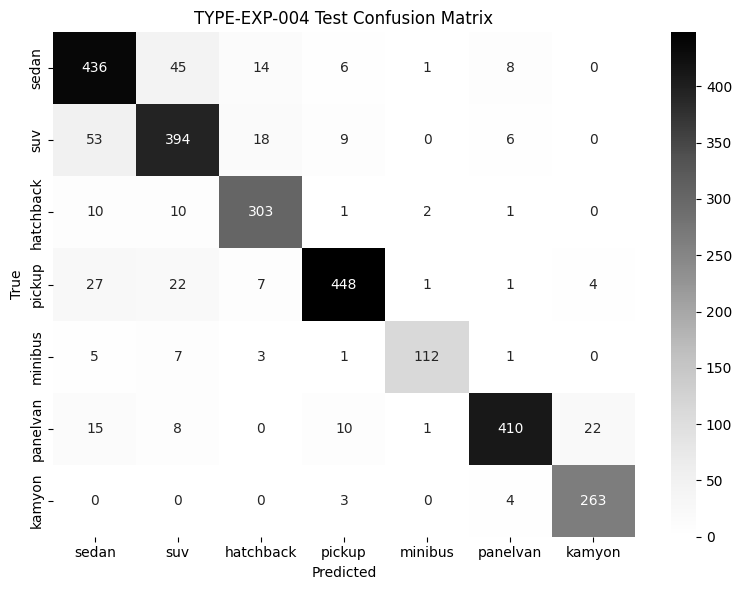

summary_json: /content/drive/MyDrive/anomali-road-safety-ai/runs/vehicle_type/TYPE-EXP-004/TYPE-EXP-004-summary.json
{
  "experiment_id": "TYPE-EXP-004",
  "parent_experiment_id": "TYPE-EXP-002",
  "parent_checkpoint": "/content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_type/TYPE-EXP-002-efficientnet_b0-best.pth",
  "best_backbone": "efficientnet_b0",
  "best_checkpoint": "/content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_type/TYPE-EXP-004-efficientnet_b0-best.pth",
  "label_map": "/content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_type/TYPE-EXP-004-label-map.json",
  "focus_labels": [
    "minibus"
  ],
  "guard_labels": [
    "sedan",
    "suv",
    "hatchback",
    "panelvan"
  ],
  "selection_config": {
    "macro": 0.35,
    "guard": 0.25,
    "minibus_f1": 0.2,
    "minibus_precision": 0.1,
    "accuracy": 0.1,
    "minibus_fp_penalty": 0.35
  },
  "val_metrics": {
    "macro_f1": 0.8675,
    "guard_macro_f1": 0.8

In [ ]:
# Cell 11 — Test evaluation, confusion matrix, promotion checks, and exports
def load_checkpoint_model(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location=device)
    model = build_model(ckpt['backbone']).to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model, ckpt

best_model, best_ckpt = load_checkpoint_model(BEST_CHECKPOINT)
val_eval = evaluate_model(best_model, val_loader)
test_eval = evaluate_model(best_model, test_loader)

print('Validation metrics:', compact_eval(val_eval))
print('Test metrics:', compact_eval(test_eval))

report_dict = classification_report(
    test_eval['labels'], test_eval['preds'], labels=list(range(NUM_CLASSES)),
    target_names=FTR_TYPE_LABELS, output_dict=True, zero_division=0,
)
report_df = pd.DataFrame(report_dict).T
report_csv = DRIVE_RUN_ROOT / f'{EXP_ID}-test_classification_report.csv'
report_df.to_csv(report_csv)
display(report_df)

cm = confusion_matrix(test_eval['labels'], test_eval['preds'], labels=list(range(NUM_CLASSES)))
cm_csv = DRIVE_RUN_ROOT / f'{EXP_ID}-test_confusion_matrix.csv'
pd.DataFrame(cm, index=FTR_TYPE_LABELS, columns=FTR_TYPE_LABELS).to_csv(cm_csv)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', xticklabels=FTR_TYPE_LABELS, yticklabels=FTR_TYPE_LABELS)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'{EXP_ID} Test Confusion Matrix')
plt.tight_layout()
cm_png = DRIVE_RUN_ROOT / f'{EXP_ID}-test_confusion_matrix.png'
plt.savefig(cm_png, dpi=180)
plt.show()

def predictions_df(eval_result):
    rows = []
    for path, true_id, pred_id, probs in zip(eval_result['paths'], eval_result['labels'], eval_result['preds'], eval_result['probs']):
        top3 = np.argsort(probs)[-3:][::-1]
        rows.append({
            'image_path': path,
            'true_label': id_to_label[int(true_id)],
            'pred_label': id_to_label[int(pred_id)],
            'confidence': float(probs[int(pred_id)]),
            'margin': float(np.sort(probs)[-1] - np.sort(probs)[-2]) if len(probs) > 1 else float(probs[int(pred_id)]),
            'is_focus_class': id_to_label[int(true_id)] in FOCUS_LABELS,
            'is_guard_class': id_to_label[int(true_id)] in GUARD_LABELS,
            'top3': json.dumps([{'label': id_to_label[int(i)], 'confidence': float(probs[int(i)])} for i in top3], ensure_ascii=False),
        })
    return pd.DataFrame(rows)

pred_csv = DRIVE_RUN_ROOT / f'{EXP_ID}-test_predictions.csv'
predictions_df(test_eval).to_csv(pred_csv, index=False)

label_map_json = DRIVE_CKPT_ROOT / f'{EXP_ID}-label-map.json'
label_map_json.write_text(json.dumps({'label_to_id': label_to_id, 'id_to_label': id_to_label, 'labels': FTR_TYPE_LABELS, 'focus_labels': FOCUS_LABELS, 'guard_labels': GUARD_LABELS}, ensure_ascii=False, indent=2), encoding='utf-8')

promotion_checks = {
    'dataset_macro_f1_ok': bool(test_eval['macro_f1'] >= PROMOTION_MIN_TEST_MACRO_F1),
    'minibus_f1_ok': bool(test_eval['minibus_f1'] >= PROMOTION_MIN_MINIBUS_F1),
    'minibus_precision_ok': bool(test_eval['minibus_precision'] >= PROMOTION_MIN_MINIBUS_PRECISION),
    'minibus_false_positive_rate_ok': bool(test_eval['minibus_false_positive_rate'] <= PROMOTION_MAX_MINIBUS_FALSE_POSITIVE_RATE),
    'local_target_roi_smoke_required': True,
    'local_target_roi_smoke_passed': None,
}
promotion_checks['dataset_promotion_candidate'] = all(v for k, v in promotion_checks.items() if k.endswith('_ok'))

summary_json = DRIVE_RUN_ROOT / f'{EXP_ID}-summary.json'
summary = {
    'experiment_id': EXP_ID,
    'parent_experiment_id': PARENT_EXP_ID,
    'parent_checkpoint': str(BASE_CHECKPOINT),
    'best_backbone': BEST_BACKBONE,
    'best_checkpoint': str(BEST_CHECKPOINT),
    'label_map': str(label_map_json),
    'focus_labels': FOCUS_LABELS,
    'guard_labels': GUARD_LABELS,
    'selection_config': {
        'macro': SELECTION_WEIGHT_MACRO,
        'guard': SELECTION_WEIGHT_GUARD,
        'minibus_f1': SELECTION_WEIGHT_MINIBUS_F1,
        'minibus_precision': SELECTION_WEIGHT_MINIBUS_PRECISION,
        'accuracy': SELECTION_WEIGHT_ACCURACY,
        'minibus_fp_penalty': MINIBUS_FP_PENALTY_WEIGHT,
    },
    'val_metrics': compact_eval(val_eval),
    'test_metrics': compact_eval(test_eval),
    'base_val_metrics': best_ckpt.get('base_val_metrics'),
    'base_test_metrics': best_ckpt.get('base_test_metrics'),
    'promotion_checks': promotion_checks,
    'train_size': len(train_df),
    'val_size': len(val_df),
    'test_size': len(test_df),
    'class_counts_raw': metadata_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(int).to_dict(),
    'class_counts_used': usable_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(int).to_dict(),
    'source_x_class_raw': pd.crosstab(metadata_df['source_dataset'], metadata_df['ftr_type']).reindex(columns=FTR_TYPE_LABELS, fill_value=0).to_dict(),
    'source_x_class_used': pd.crosstab(usable_df['source_dataset'], usable_df['ftr_type']).reindex(columns=FTR_TYPE_LABELS, fill_value=0).to_dict(),
    'artifacts': {
        'metadata_csv': str(metadata_csv),
        'splits_csv': str(splits_csv),
        'backbone_summary_csv': str(summary_path),
        'classification_report_csv': str(report_csv),
        'confusion_matrix_csv': str(cm_csv),
        'confusion_matrix_png': str(cm_png),
        'test_predictions_csv': str(pred_csv),
        'label_map_json': str(label_map_json),
    },
}
summary_json.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
print('summary_json:', summary_json)
print(json.dumps(summary, ensure_ascii=False, indent=2)[:4000])


In [ ]:
# Cell 12 — Optional target ROI smoke inference from existing project crops
SMOKE_CROP_CANDIDATES = [
    PROJECT_ROOT / 'runs' / '_archive' / 'plate_ocr_v1_POCR-EXP-001-target-roi-crops' / 'sample_frames',
    PROJECT_ROOT / 'runs' / 'plate_ocr' / 'POCR-EXP-001-target-roi-crops' / 'sample_frames',
    LOCAL_ROOT / 'runs' / '_archive' / 'plate_ocr_v1_POCR-EXP-001-target-roi-crops' / 'sample_frames',
]

SMOKE_MIN_CONFIDENCE = 0.60
SMOKE_MIN_MARGIN = 0.15

def predict_image(path):
    image = Image.open(path).convert('RGB')
    tensor = eval_tf(image).unsqueeze(0).to(device)
    with torch.no_grad():
        probs = torch.softmax(best_model(tensor), dim=1).cpu().numpy().reshape(-1)
    top = int(np.argmax(probs))
    sorted_idx = np.argsort(probs)
    second = int(sorted_idx[-2]) if len(probs) > 1 else top
    margin = float(probs[top] - probs[second])
    return {
        'crop_uri': str(path),
        'pred_type': id_to_label[top],
        'confidence': float(probs[top]),
        'margin': margin,
        'gate_pass': bool(float(probs[top]) >= SMOKE_MIN_CONFIDENCE and margin >= SMOKE_MIN_MARGIN),
        'top3': json.dumps([{'label': id_to_label[int(idx)], 'confidence': float(probs[int(idx)])} for idx in sorted_idx[-3:][::-1]], ensure_ascii=False),
    }

smoke_dir = next((p for p in SMOKE_CROP_CANDIDATES if p.exists() and any(p.glob('*.jpg'))), None)
if smoke_dir is None:
    print('No target ROI crop folder found. Smoke inference skipped. Local Mac smoke test remains mandatory before freeze.')
else:
    crop_paths = sorted(smoke_dir.glob('*.jpg'))
    smoke_rows = [predict_image(p) for p in tqdm(crop_paths, desc='target ROI smoke')]
    smoke_df = pd.DataFrame(smoke_rows)
    smoke_csv = DRIVE_RUN_ROOT / f'{EXP_ID}-target_roi_smoke_predictions.csv'
    smoke_df.to_csv(smoke_csv, index=False)
    print('smoke_csv:', smoke_csv)
    display(smoke_df['pred_type'].value_counts().to_frame('count'))
    display(smoke_df[smoke_df['gate_pass']]['pred_type'].value_counts().to_frame('gated_count'))
    display(smoke_df.head(20))


No target ROI crop folder found. Smoke inference skipped. Local Mac smoke test remains mandatory before freeze.


In [ ]:
# Cell 13 — Markdown run report
report_md = DRIVE_RUN_ROOT / f'{EXP_ID}-run_summary.md'
lines = [
    f'# {EXP_ID} T4 Controlled Minibus Repair Summary',
    '',
    f'- Parent experiment: `{PARENT_EXP_ID}`',
    f'- Parent checkpoint: `{BASE_CHECKPOINT}`',
    f'- Best backbone: `{BEST_BACKBONE}`',
    f'- Best checkpoint: `{BEST_CHECKPOINT}`',
    f'- Validation macro-F1: `{val_eval["macro_f1"]:.4f}`',
    f'- Validation guard macro-F1: `{val_eval["guard_macro_f1"]:.4f}`',
    f'- Validation minibus F1: `{val_eval["minibus_f1"]:.4f}`',
    f'- Validation minibus precision: `{val_eval["minibus_precision"]:.4f}`',
    f'- Validation minibus false-positive rate: `{val_eval["minibus_false_positive_rate"]:.4f}`',
    f'- Validation selection score: `{val_eval["selection_score"]:.4f}`',
    f'- Test macro-F1: `{test_eval["macro_f1"]:.4f}`',
    f'- Test guard macro-F1: `{test_eval["guard_macro_f1"]:.4f}`',
    f'- Test minibus F1: `{test_eval["minibus_f1"]:.4f}`',
    f'- Test minibus precision: `{test_eval["minibus_precision"]:.4f}`',
    f'- Test minibus false-positive rate: `{test_eval["minibus_false_positive_rate"]:.4f}`',
    f'- Test selection score: `{test_eval["selection_score"]:.4f}`',
    f'- Test accuracy: `{test_eval["accuracy"]:.4f}`',
    f'- Train/val/test: `{len(train_df)}/{len(val_df)}/{len(test_df)}`',
    '',
    '## FTR Labels',
    '',
    ', '.join(f'`{x}`' for x in FTR_TYPE_LABELS),
    '',
    '## Focus / Guard Labels',
    '',
    f'- Focus: ' + ', '.join(f'`{x}`' for x in FOCUS_LABELS),
    f'- Guard: ' + ', '.join(f'`{x}`' for x in GUARD_LABELS),
    '',
    '## Data Strategy',
    '',
    '- TYPE-EXP-002 base sources are retained for all 7 FTR labels.',
    '- Vehicle-10 minibus data is capped; it is not allowed to dominate the split.',
    '- Class weights and sampler weights are clipped to avoid repeating TYPE-EXP-003 minibus over-correction.',
    '- Model selection penalizes minibus false positives and rewards minibus precision, not only recall.',
    '',
    '## Class Counts Used',
    '',
]
for label, count in usable_df['ftr_type'].value_counts().reindex(FTR_TYPE_LABELS).fillna(0).astype(int).items():
    focus_mark = ' (focus)' if label in FOCUS_LABELS else ' (guard)' if label in GUARD_LABELS else ''
    lines.append(f'- `{label}`{focus_mark}: {count}')
lines.extend([
    '',
    '## Promotion Checks',
    '',
])
for key, value in promotion_checks.items():
    lines.append(f'- `{key}`: `{value}`')
lines.extend([
    '',
    '## Important Notes',
    '',
    '- This is a controlled repair run, not a final runtime promotion.',
    '- A good notebook result is insufficient unless the same 3 local target ROI video smoke tests pass.',
    '- Promotion requires no minibus false mode on the active demo target tracks.',
    '- If dataset-level minibus improves but local SUV target tracks regress, keep TYPE-EXP-002 as runtime baseline.',
    '',
    '## Artifacts',
    '',
    f'- Summary JSON: `{summary_json}`',
    f'- Label map: `{label_map_json}`',
    f'- Classification report CSV: `{report_csv}`',
    f'- Confusion matrix PNG: `{cm_png}`',
])
report_md.write_text('\n'.join(lines), encoding='utf-8')
print('report_md:', report_md)
print('\n'.join(lines[:110]))


report_md: /content/drive/MyDrive/anomali-road-safety-ai/runs/vehicle_type/TYPE-EXP-004/TYPE-EXP-004-run_summary.md
# TYPE-EXP-004 T4 Controlled Minibus Repair Summary

- Parent experiment: `TYPE-EXP-002`
- Parent checkpoint: `/content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_type/TYPE-EXP-002-efficientnet_b0-best.pth`
- Best backbone: `efficientnet_b0`
- Best checkpoint: `/content/drive/MyDrive/anomali-road-safety-ai/models/checkpoints/vehicle_type/TYPE-EXP-004-efficientnet_b0-best.pth`
- Validation macro-F1: `0.8675`
- Validation guard macro-F1: `0.8486`
- Validation minibus F1: `0.8675`
- Validation minibus precision: `0.9000`
- Validation minibus false-positive rate: `0.0047`
- Validation selection score: `0.8637`
- Test macro-F1: `0.8880`
- Test guard macro-F1: `0.8644`
- Test minibus F1: `0.9106`
- Test minibus precision: `0.9573`
- Test minibus false-positive rate: `0.0020`
- Test selection score: `0.8919`
- Test accuracy: `0.8789`
- Train/val/test: `12558